# Comprehensive Forecast Analysis (AutoGluon)
This notebook provides a complete analysis of the forecasting model performance.
It includes:
1.  **Metric Analysis**: MAE, RMSE, and Normalized Error % (WAPE).
2.  **Top/Bottom Performers**: Identifying the best and worst predicted tanks.
3.  **Individual Forecast Plots**: Detailed "Actual vs Model" charts with confidence intervals.
4.  **Global Diagnostics**: Scatter plots, Residual histograms, and Hourly Patterns.
5.  **Full Report**: A loop to generate plots for every tank in the system.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Libraries imported and plot style configured.")

Libraries imported and plot style configured.


In [11]:
# --- CONFIGURATION (Paths) ---
# NOTE: We use "holdout_predictions_readable.csv" because it includes the "actual" column.
PRED_PATH = "../results/autogluon/hourly_forecasting/holdout_predictions_readable.csv"
METRICS_PATH = "../results/autogluon/hourly_forecasting/holdout_per_tank_metrics.csv"

# --- LOAD DATA ---
try:
    df_pred = pd.read_csv(PRED_PATH)
    df_metrics = pd.read_csv(METRICS_PATH)
    print(f"Data loaded successfully.")
    print(f"Predictions: {len(df_pred)} rows")
    print(f"Metrics: {len(df_metrics)} tanks")

    # Convert timestamps
    df_pred["timestamp"] = pd.to_datetime(df_pred["timestamp"])

except FileNotFoundError as e:
    print(f"ERROR: Could not find files. Make sure you ran 'run_forecast.sh' first.\n{e}")
    
df_metrics.head()

Data loaded successfully.
Predictions: 576 rows
Metrics: 24 tanks


,item_id,rows_evaluated,mae,rmse,mean_actual,mean_pred,p10_p90_coverage
0,G_BLOCK,24,1.095778,2.608470,1.021250,1.057500,0.833333
1,BE_BLOCK_OHT,24,0.781653,0.906912,1.097083,1.727958,0.875000
2,GJBC_LAW_BLOCK_3_A4_BOYS,24,0.727639,1.244859,1.398333,1.046722,0.708333
3,I&H_BLOCK,24,0.686931,0.889281,0.690417,0.003486,0.416667
4,GJBC_LAW_BLOCK_3__A1,24,0.635472,1.626870,0.978750,0.430917,0.791667


In [12]:
# --- CALCULATION OF FAIR METRICS ---
# Why Normalized Error?
# A tank with 1000L usage and 10L error is GREAT (1%).
# A tank with 20L usage and 10L error is TERRIBLE (50%).
# Standard MAE makes big tanks look worse.

# Formula: Error % = (MAE / Mean_Actual) * 100

# 1. Handle inactive tanks (Mean_Actual near 0)
df_metrics["mean_actual_safe"] = df_metrics["mean_actual"].replace(0, 0.001)

# 2. Compute Relative Error
df_metrics["error_pct"] = (df_metrics["mae"] / df_metrics["mean_actual_safe"]) * 100

# 3. Cap display (for readability)
df_metrics["error_pct_display"] = df_metrics["error_pct"].clip(upper=200)

print("Calculation complete.")
df_metrics[["item_id", "mae", "mean_actual", "error_pct"]].head()

Calculation complete.


,item_id,mae,mean_actual,error_pct
0,G_BLOCK,1.095778,1.021250,107.297702
1,BE_BLOCK_OHT,0.781653,1.097083,71.248259
2,GJBC_LAW_BLOCK_3_A4_BOYS,0.727639,1.398333,52.036154
3,I&H_BLOCK,0.686931,0.690417,99.495071
4,GJBC_LAW_BLOCK_3__A1,0.635472,0.978750,64.926919


In [13]:
# --- DISPLAY TOP/BOTTOM TABLES ---

cols = ["item_id", "mae", "mean_actual", "error_pct"]

print("--- TOP 5 BEST TANKS (Lowest Relative Error %) ---")
# Lowest % Error = Most reliable prediction
best = df_metrics.sort_values("error_pct", ascending=True).head(5)[cols]
display(best)
print("\n*Note: High MAE but Low % Error means the tank is HUGE but well-predicted.*")


print("\n--- TOP 5 WORST TANKS (Highest Relative Error %) ---")
# Highest % Error = Needs investigation (Erratic, Silent, or Noisy)
worst = df_metrics.sort_values("error_pct", ascending=False).head(5)[cols]
display(worst)
print("*Note: These tanks are the most difficult for the model.*")

--- TOP 5 BEST TANKS (Lowest Relative Error %) ---


,item_id,mae,mean_actual,error_pct
23,NEW_BLOCK_RO,0.000000,0.000000,0.000000
17,NEW_BLOCK,0.034278,0.163333,20.986395
12,GJBC_LAW_BLOCK_3__A3_GIRLS,0.141056,0.430417,32.771862
6,MM_BLOCK,0.386417,1.131667,34.145803
11,GJBC_LAW_BLOCK_3__A2,0.200958,0.510417,39.371429



*Note: High MAE but Low % Error means the tank is HUGE but well-predicted.*

--- TOP 5 WORST TANKS (Highest Relative Error %) ---


,item_id,mae,mean_actual,error_pct
21,CRICKET_GROUND_OHT,0.006056,0.004583,132.121212
0,G_BLOCK,1.095778,1.021250,107.297702
22,GJBC_BLOCK_1_A4_RO,0.000847,0.000833,101.666667
3,I&H_BLOCK,0.686931,0.690417,99.495071
20,INFORMATION_CENTRE,0.018153,0.018750,96.814815


*Note: These tanks are the most difficult for the model.*


Testing Plot Function...
1. Plotting Best Tank (Low Error %)


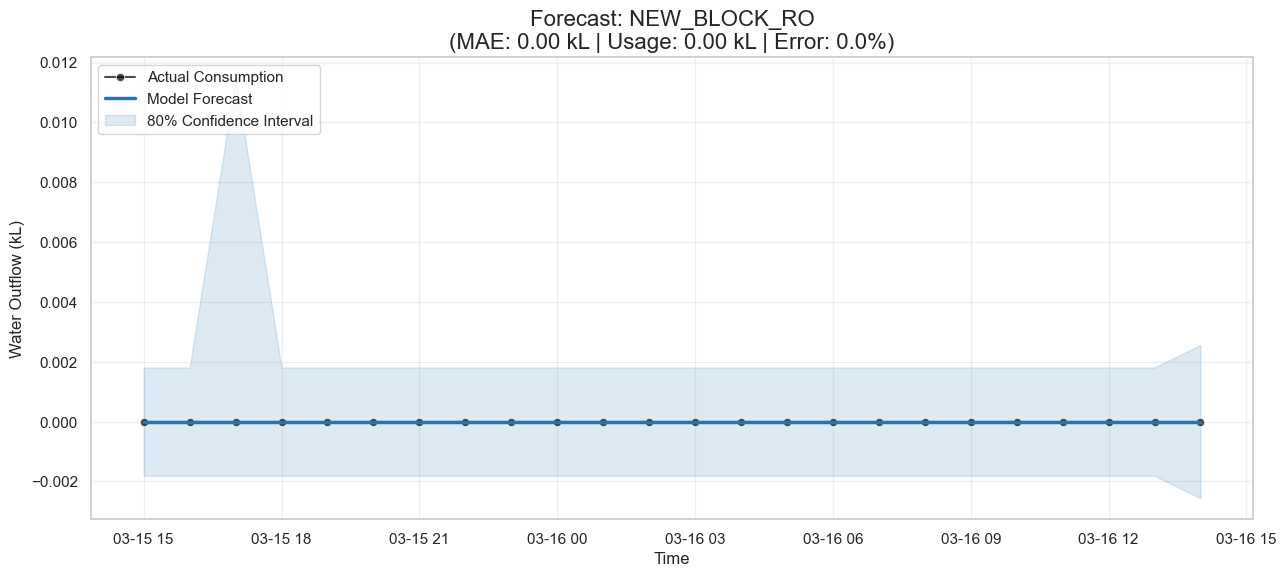

2. Plotting Worst Tank (High Error %)


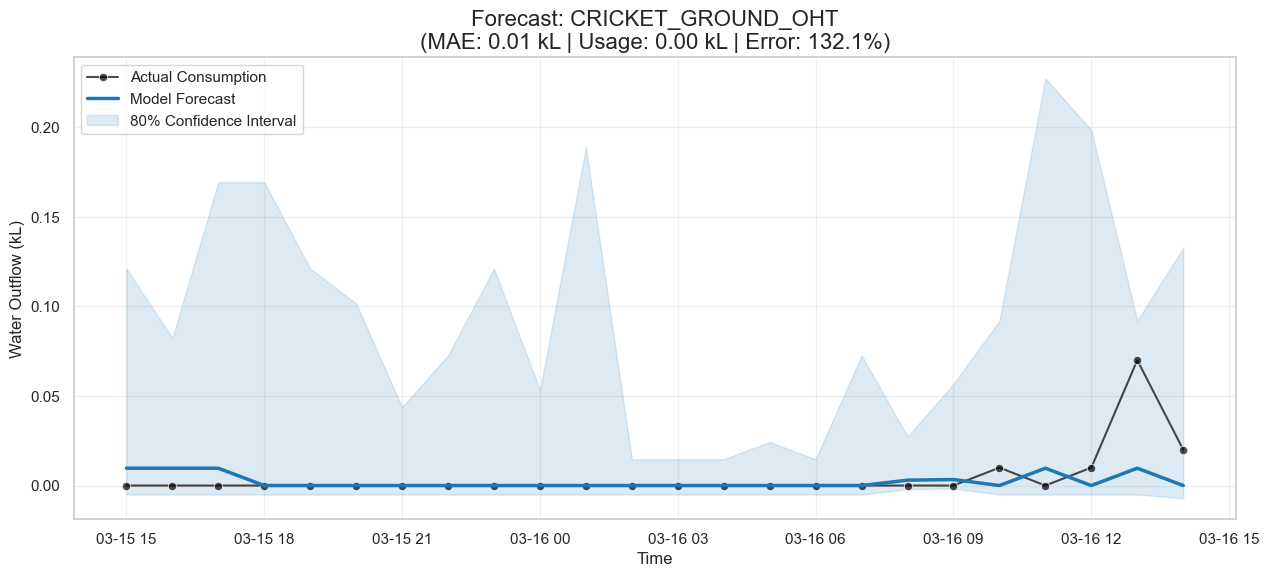

In [14]:
# --- PLOTTING FUNCTION ---
def plot_tank_forecast(item_id):
    """Plots actual vs predicted values for a specific tank."""
    
    # Filter data for this tank
    tank_data = df_pred[df_pred["item_id"] == item_id].sort_values("timestamp")
    
    # Get metrics
    row = df_metrics[df_metrics["item_id"] == item_id]
    mae = row["mae"].values[0]
    mean_val = row["mean_actual"].values[0]
    err_pct = row["error_pct"].values[0]
    
    plt.figure(figsize=(15, 6))
    
    # 1. Plot Actual
    sns.lineplot(data=tank_data, x="timestamp", y="actual", label="Actual Consumption", color="black", marker="o", alpha=0.7)
    
    # 2. Plot Predicted (Mean)
    sns.lineplot(data=tank_data, x="timestamp", y="pred_mean", label="Model Forecast", color="#1f77b4", linewidth=2.5)
    
    # 3. Plot Prediction Intervals (Blue Band)
    plt.fill_between(
        tank_data["timestamp"], 
        tank_data["pred_p10"], 
        tank_data["pred_p90"], 
        color="#1f77b4", alpha=0.15, label="80% Confidence Interval"
    )
    
    plt.title(f"Forecast: {item_id}\n(MAE: {mae:.2f} kL | Usage: {mean_val:.2f} kL | Error: {err_pct:.1f}%)", fontsize=16)
    plt.ylabel("Water Outflow (kL)")
    plt.xlabel("Time")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

# Test plots
print("Testing Plot Function...")
print("1. Plotting Best Tank (Low Error %)")
plot_tank_forecast(best.iloc[0]["item_id"])

print("2. Plotting Worst Tank (High Error %)")
plot_tank_forecast(worst.iloc[0]["item_id"])

--- SYSTEM-WIDE HOURLY USAGE ---


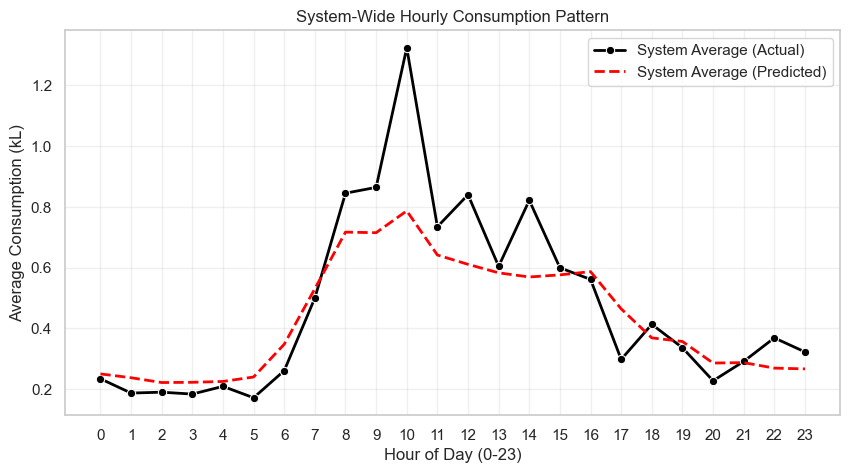

In [15]:
# --- HOURLY AGGREGATION PLOT ---
# Helps identify "Morning Spike" (6-9 AM) and "Evening Spike" (6-9 PM)
# This averages ALL tanks to show the system-wide pattern.

print("--- SYSTEM-WIDE HOURLY USAGE ---")

# Extract Hour
df_pred["hour"] = df_pred["timestamp"].dt.hour

# Calculate Mean for Actual and Predicted
hourly_stats = df_pred.groupby("hour")[["actual", "pred_mean"]].mean()

plt.figure(figsize=(10, 5))

# Plot Lines
sns.lineplot(data=hourly_stats, x="hour", y="actual", label="System Average (Actual)", color="black", marker="o", linewidth=2)
sns.lineplot(data=hourly_stats, x="hour", y="pred_mean", label="System Average (Predicted)", color="red", linestyle="--", linewidth=2)

plt.title("System-Wide Hourly Consumption Pattern")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average Consumption (kL)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/var/folders/0r/g3wkpt1x0_36_7mmzc93xz4m0000gn/T/ipykernel_94790/3634711320.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_mae, y="item_id", x="mae", palette="Blues_d")
/var/folders/0r/g3wkpt1x0_36_7mmzc93xz4m0000gn/T/ipykernel_94790/3634711320.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_pct, y="item_id", x="error_pct_display", palette="Reds_d")


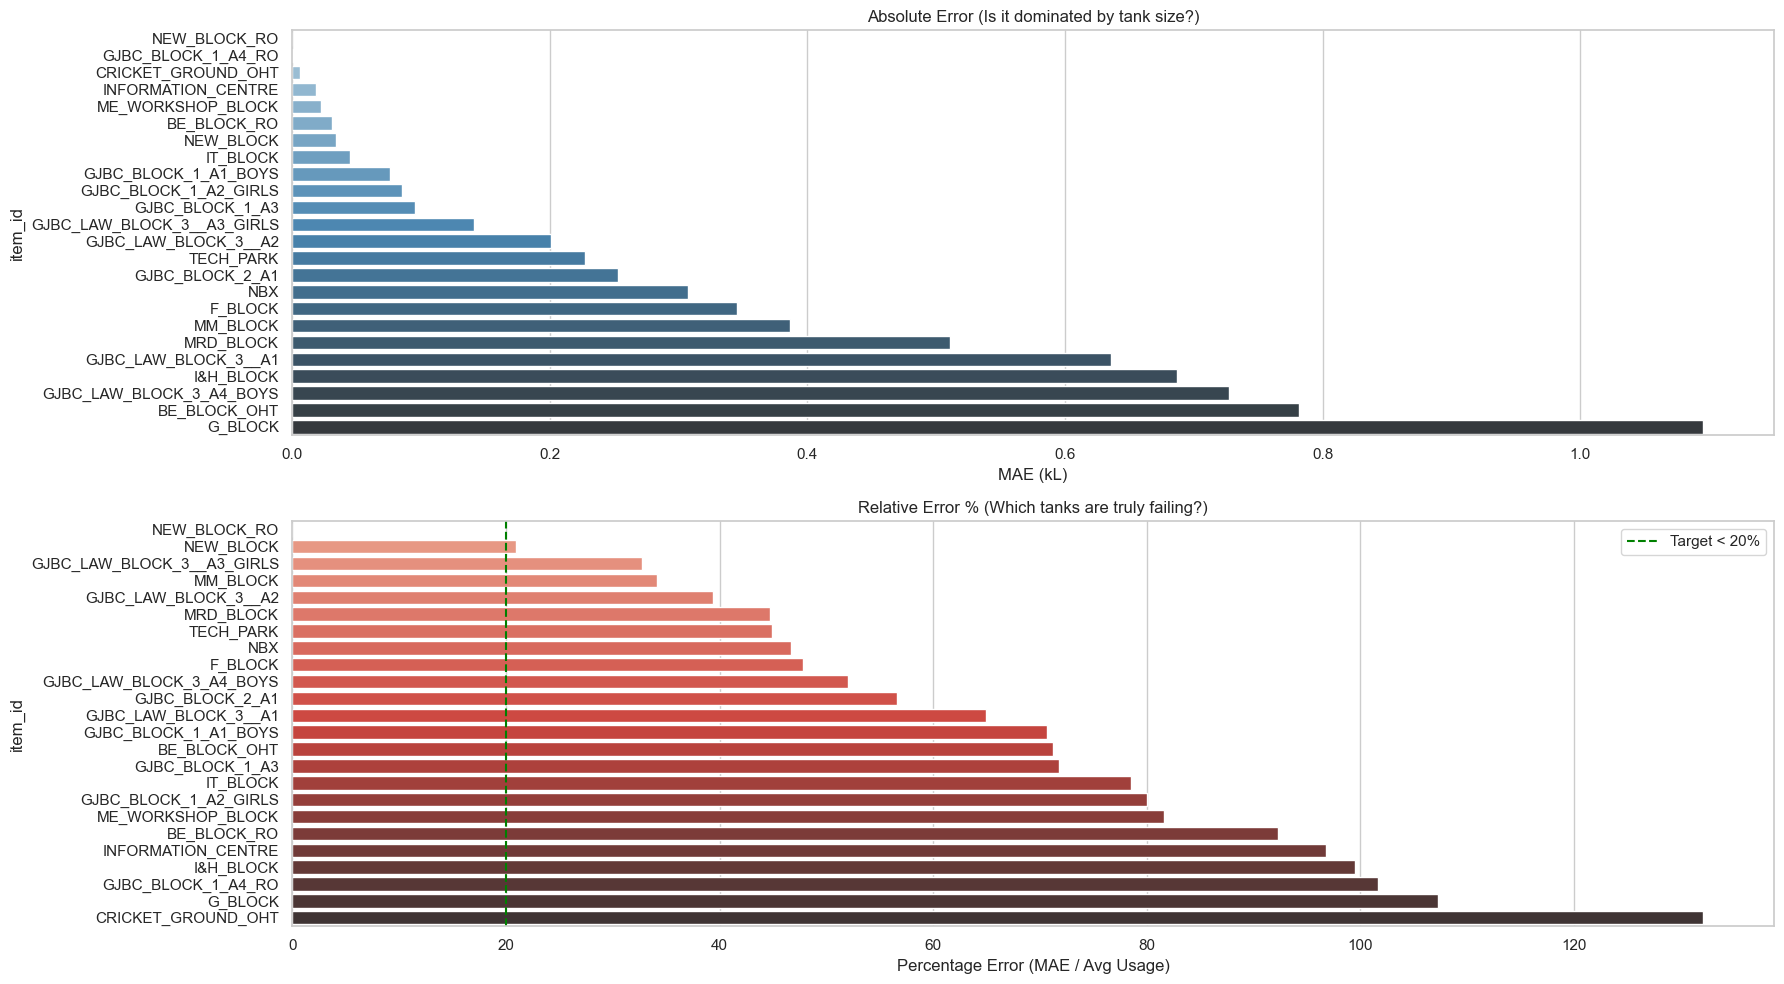

In [16]:
# --- RELATIVE ERROR CHART ---
# Shows "MAE" vs "Normalized Error %" side-by-side.
# Helps distinguish between BIG tanks and BADLY PREDICTED tanks.

plt.figure(figsize=(18, 10))

# Subplot 1: Absolute Errors (MAE)
plt.subplot(2, 1, 1)
df_sorted_mae = df_metrics.sort_values("mae", ascending=True)
sns.barplot(data=df_sorted_mae, y="item_id", x="mae", palette="Blues_d")
plt.title("Absolute Error (Is it dominated by tank size?)")
plt.xlabel("MAE (kL)")

# Subplot 2: Relative Errors (% Error)
plt.subplot(2, 1, 2)
df_sorted_pct = df_metrics.sort_values("error_pct", ascending=True)
sns.barplot(data=df_sorted_pct, y="item_id", x="error_pct_display", palette="Reds_d")
plt.axvline(20, color="green", linestyle="--", label="Target < 20%")
plt.title("Relative Error % (Which tanks are truly failing?)")
plt.xlabel("Percentage Error (MAE / Avg Usage)")
plt.legend()

plt.tight_layout()
plt.show()

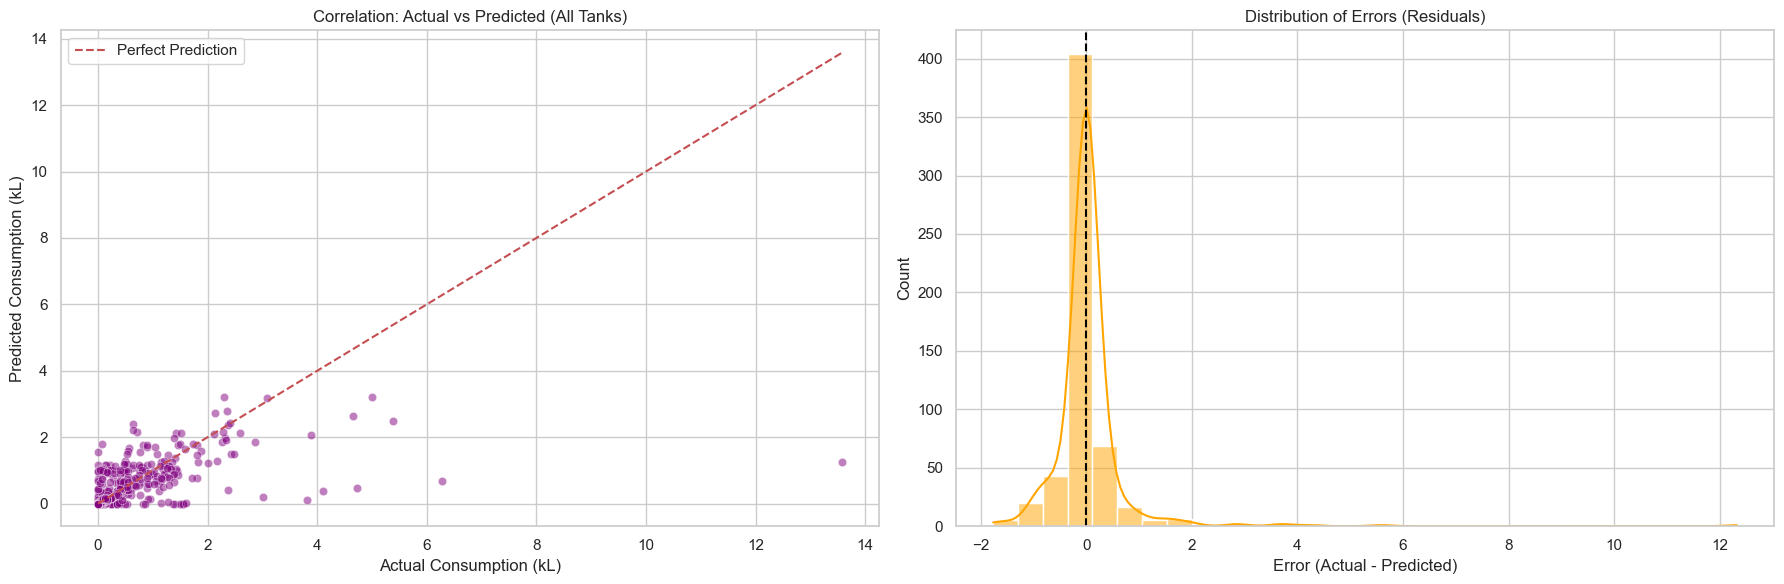

Overall Correlation: 0.5684


In [17]:
# --- PLOT 1: SCATTER & RESIDUALS ---
# Helps identify bias (overestimation vs underestimation)

plt.figure(figsize=(18, 6))

# Subplot 1: Actual vs Predicted Scatter
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_pred, x="actual", y="pred_mean", alpha=0.5, color="purple")
max_val = max(df_pred["actual"].max(), df_pred["pred_mean"].max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect Prediction")
plt.title("Correlation: Actual vs Predicted (All Tanks)")
plt.xlabel("Actual Consumption (kL)")
plt.ylabel("Predicted Consumption (kL)")
plt.legend()

# Subplot 2: Error Histogram
plt.subplot(1, 2, 2)
sns.histplot(df_pred["error"], kde=True, color="orange", bins=30)
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribution of Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")

plt.tight_layout()
plt.show()

print(f"Overall Correlation: {df_pred['actual'].corr(df_pred['pred_mean']):.4f}")

Generating plots for ALL tanks in the dataset...


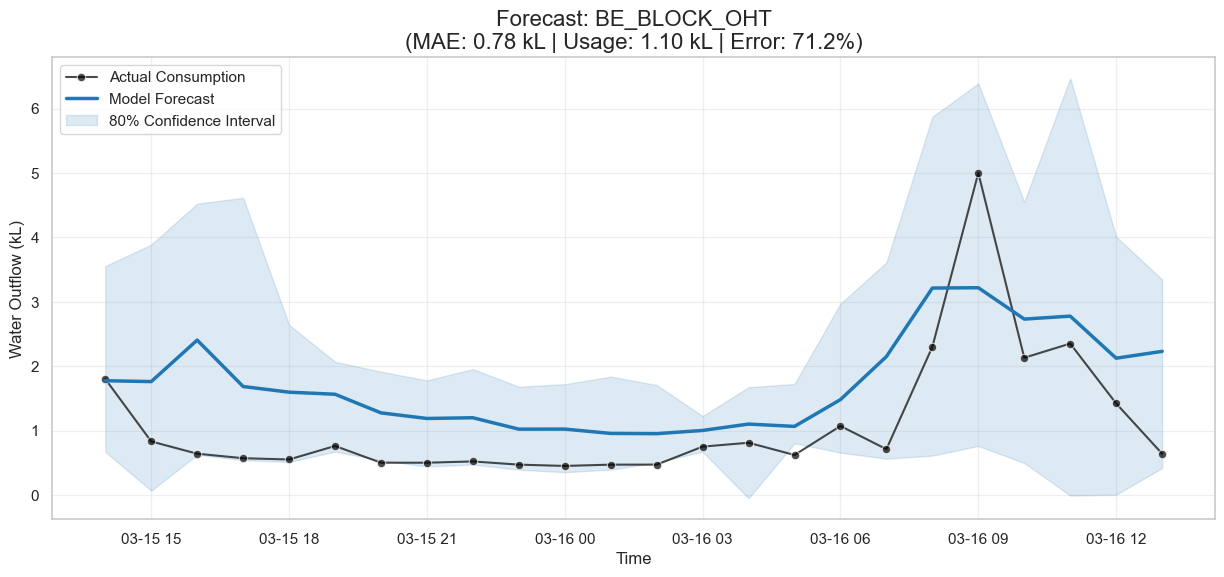

Generated plot: BE_BLOCK_OHT


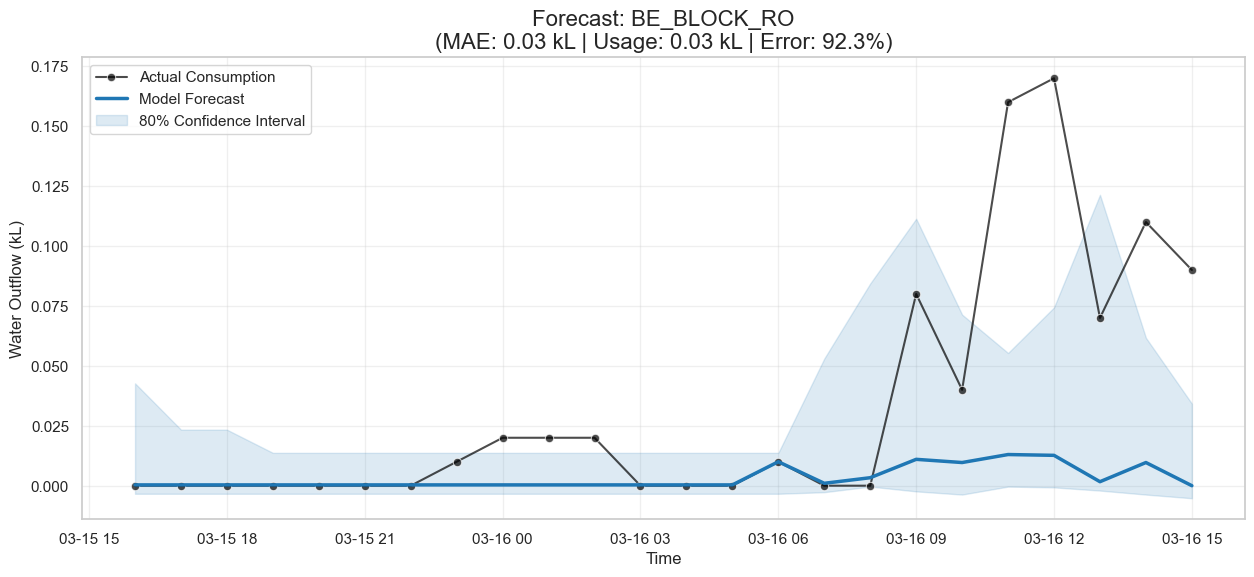

Generated plot: BE_BLOCK_RO


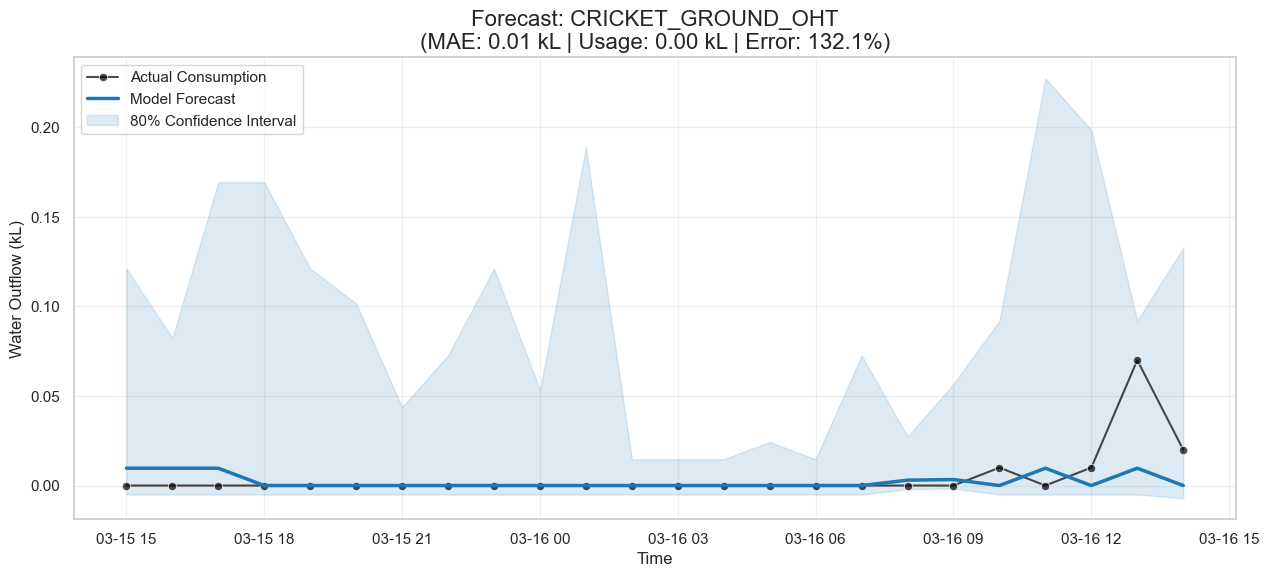

Generated plot: CRICKET_GROUND_OHT


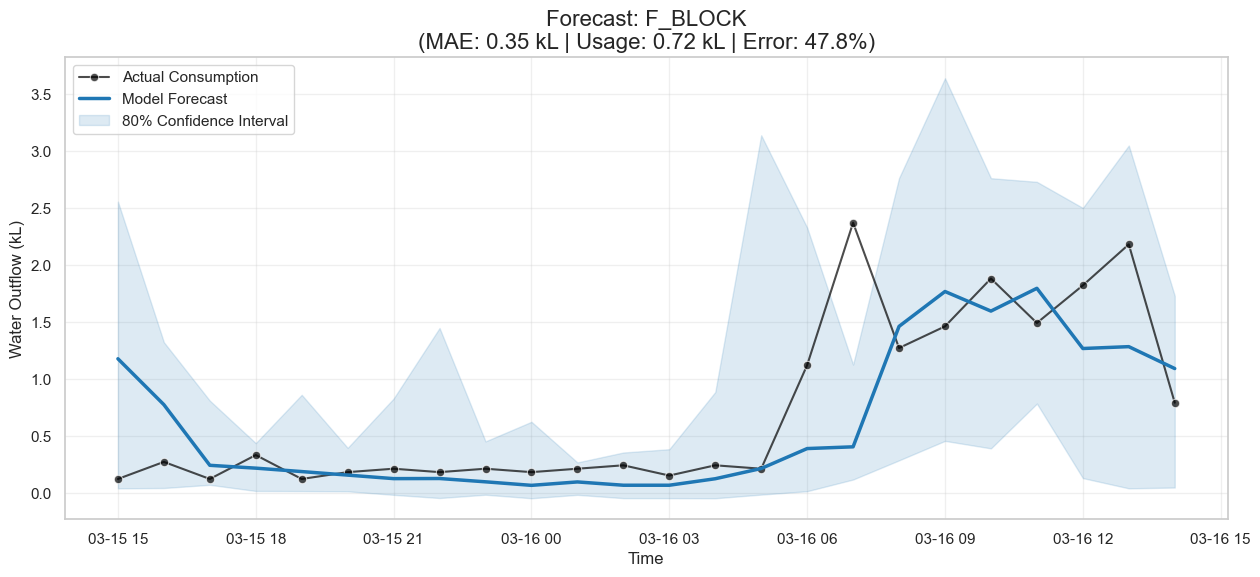

Generated plot: F_BLOCK


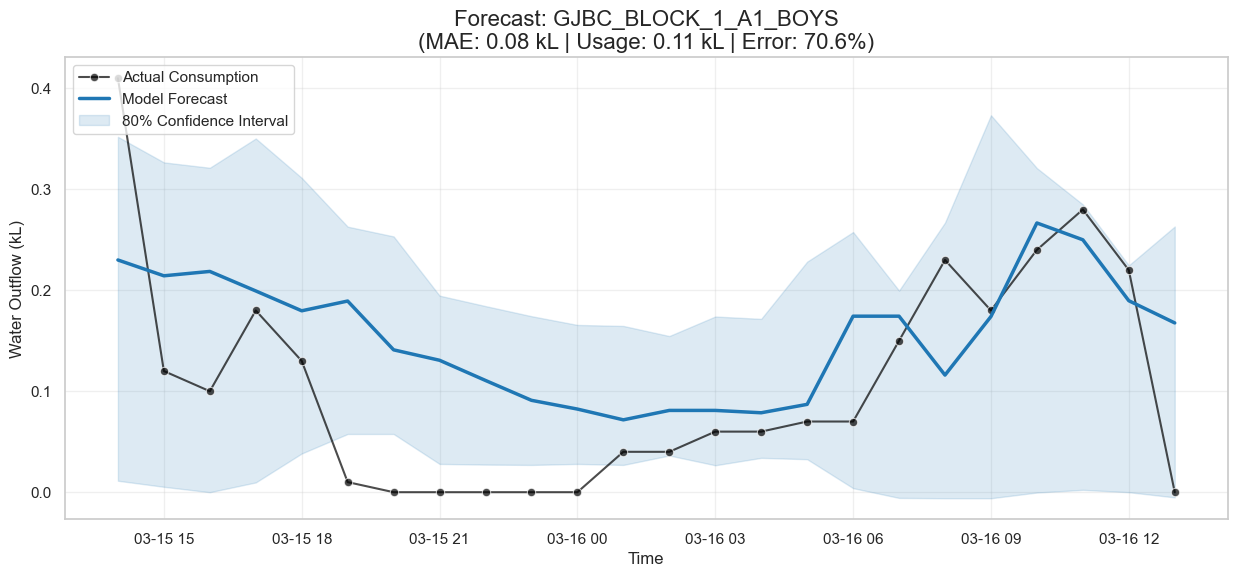

Generated plot: GJBC_BLOCK_1_A1_BOYS


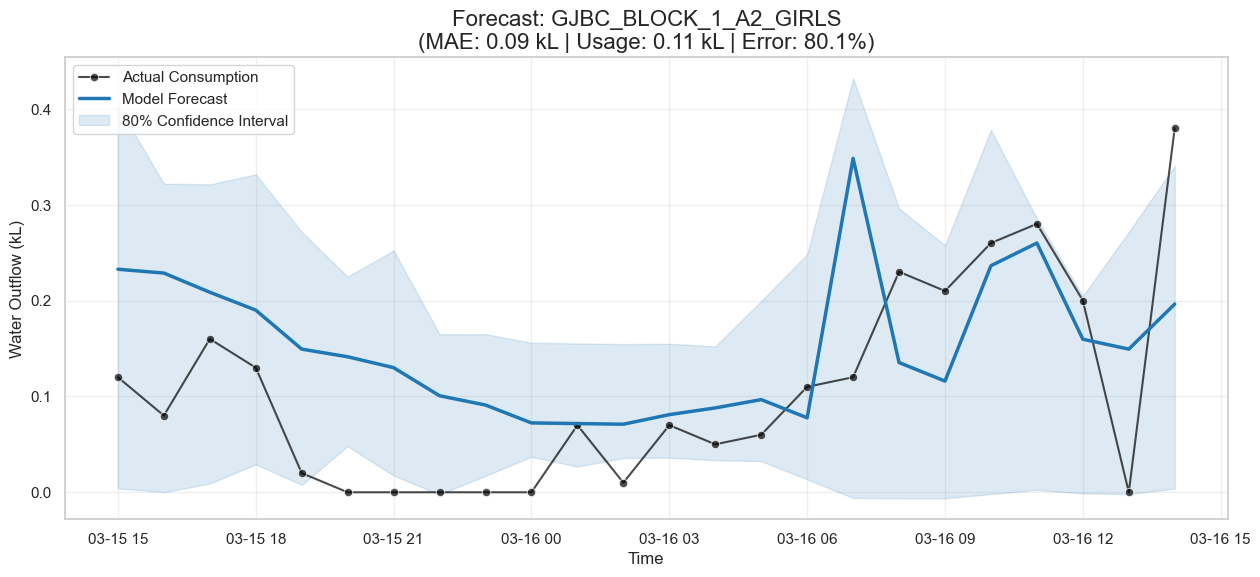

Generated plot: GJBC_BLOCK_1_A2_GIRLS


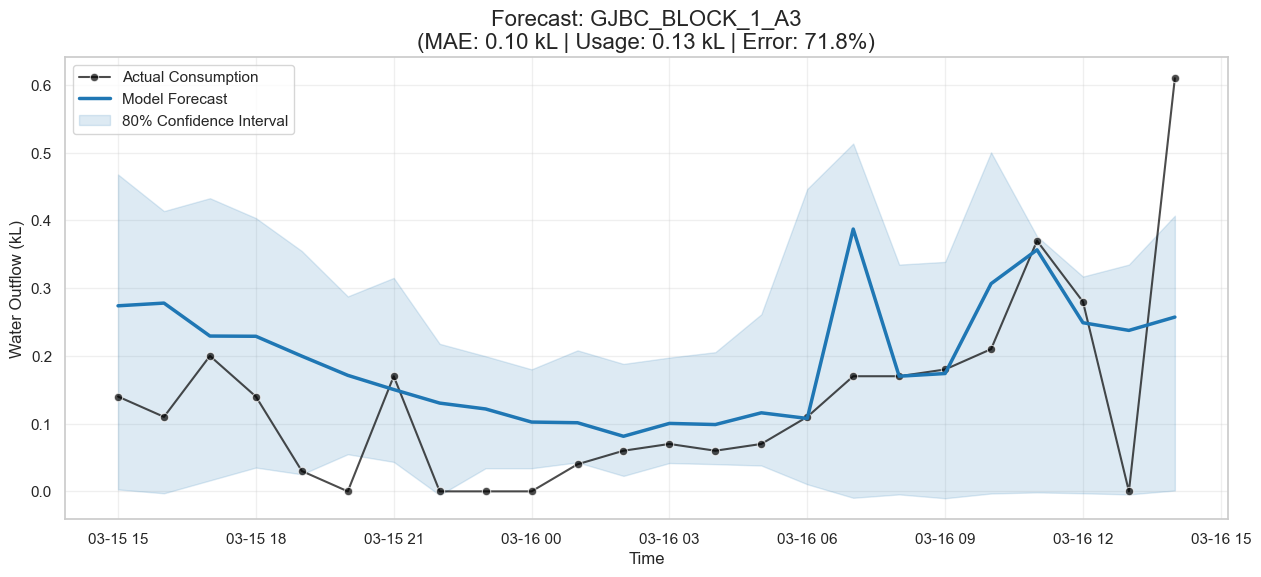

Generated plot: GJBC_BLOCK_1_A3


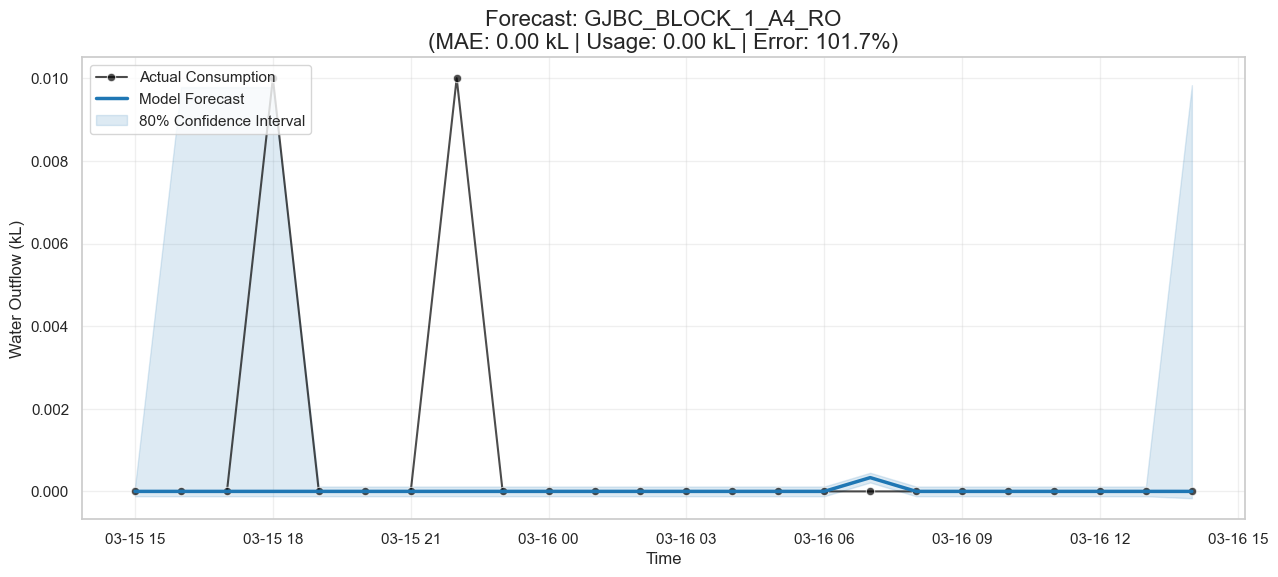

Generated plot: GJBC_BLOCK_1_A4_RO


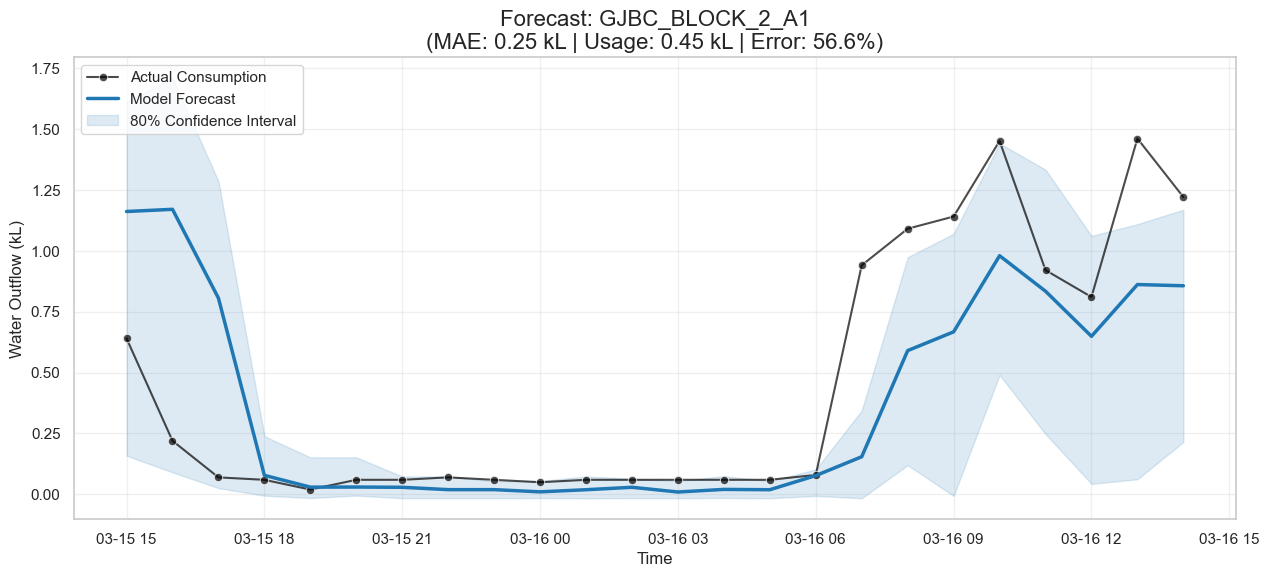

Generated plot: GJBC_BLOCK_2_A1


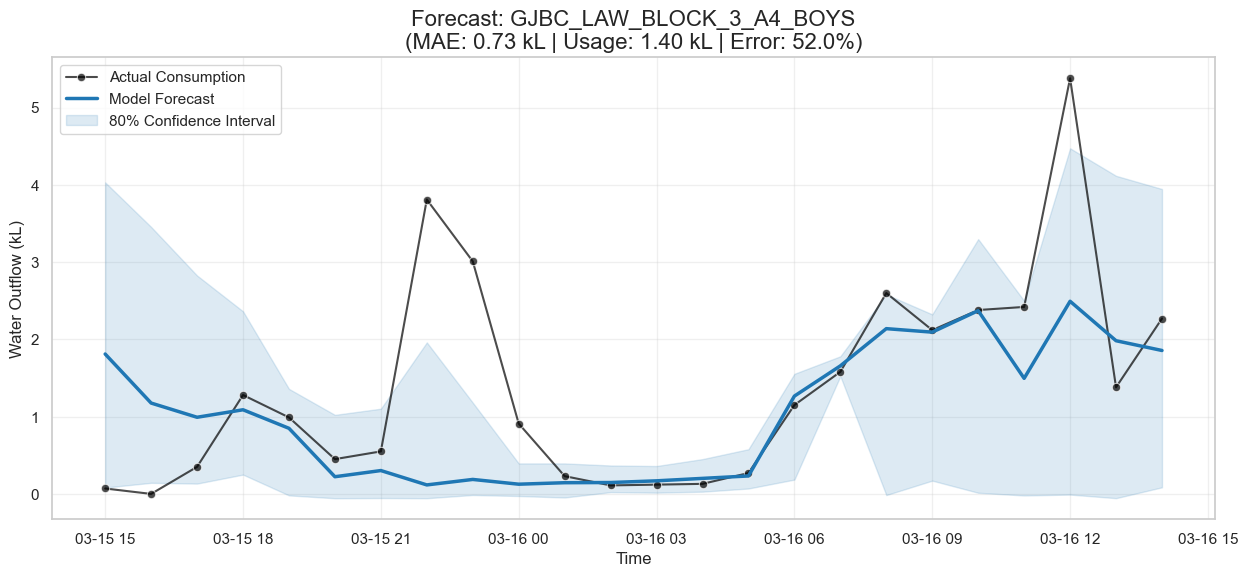

Generated plot: GJBC_LAW_BLOCK_3_A4_BOYS


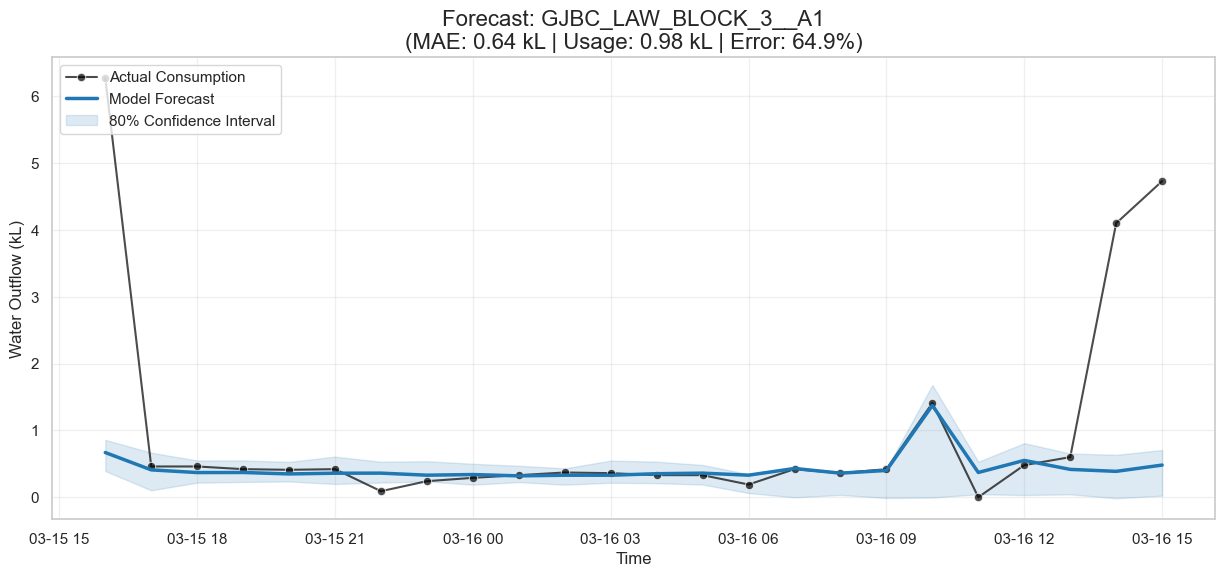

Generated plot: GJBC_LAW_BLOCK_3__A1


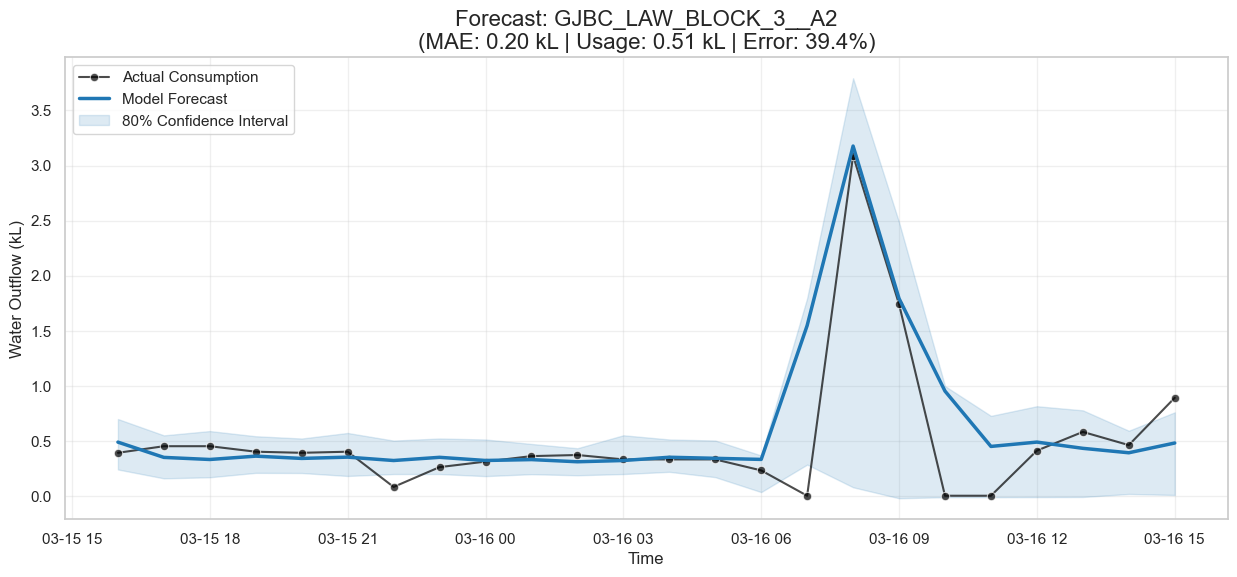

Generated plot: GJBC_LAW_BLOCK_3__A2


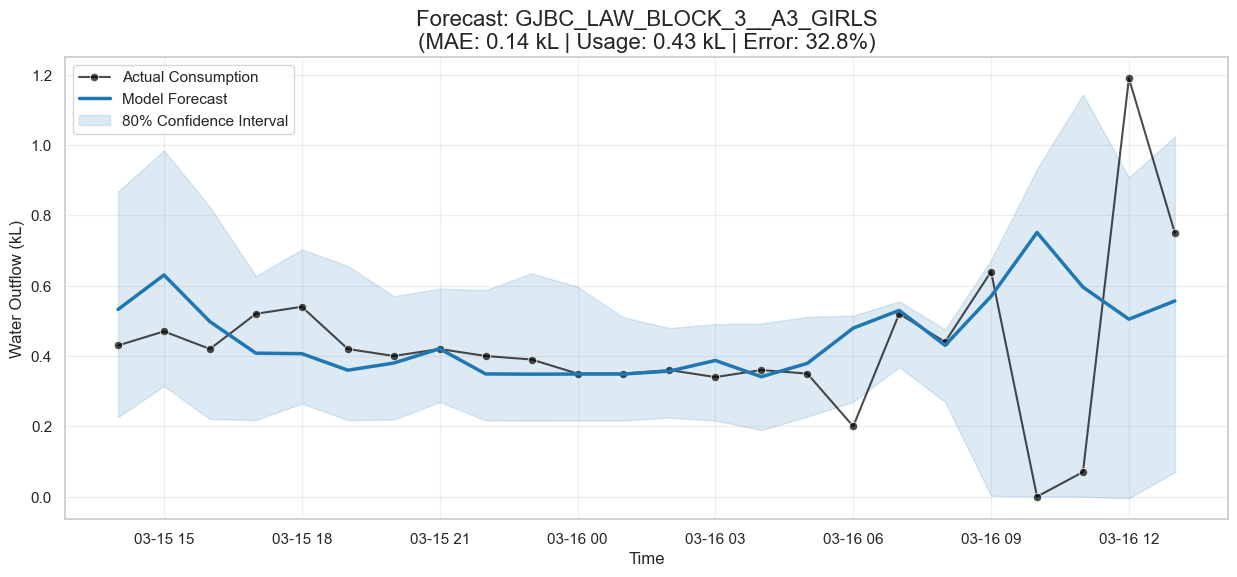

Generated plot: GJBC_LAW_BLOCK_3__A3_GIRLS


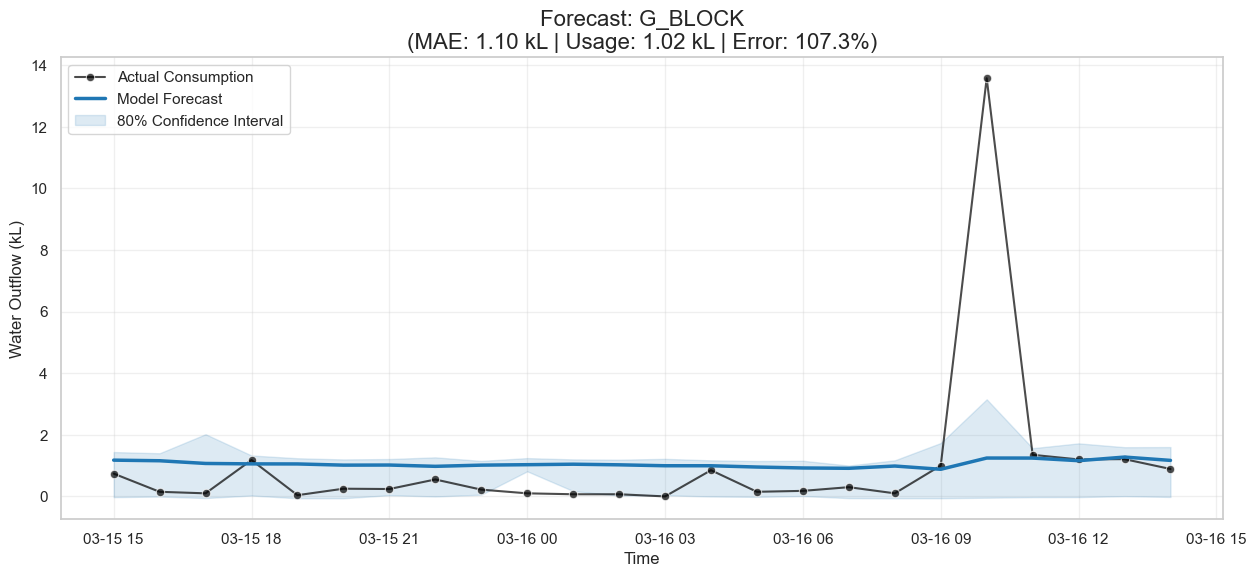

Generated plot: G_BLOCK


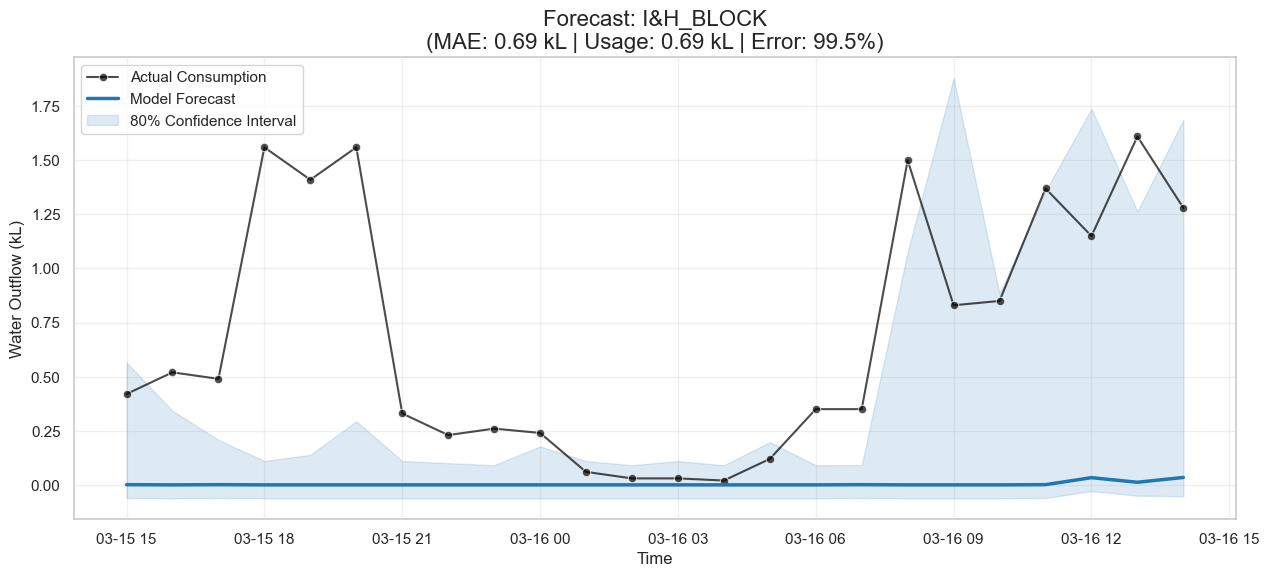

Generated plot: I&H_BLOCK


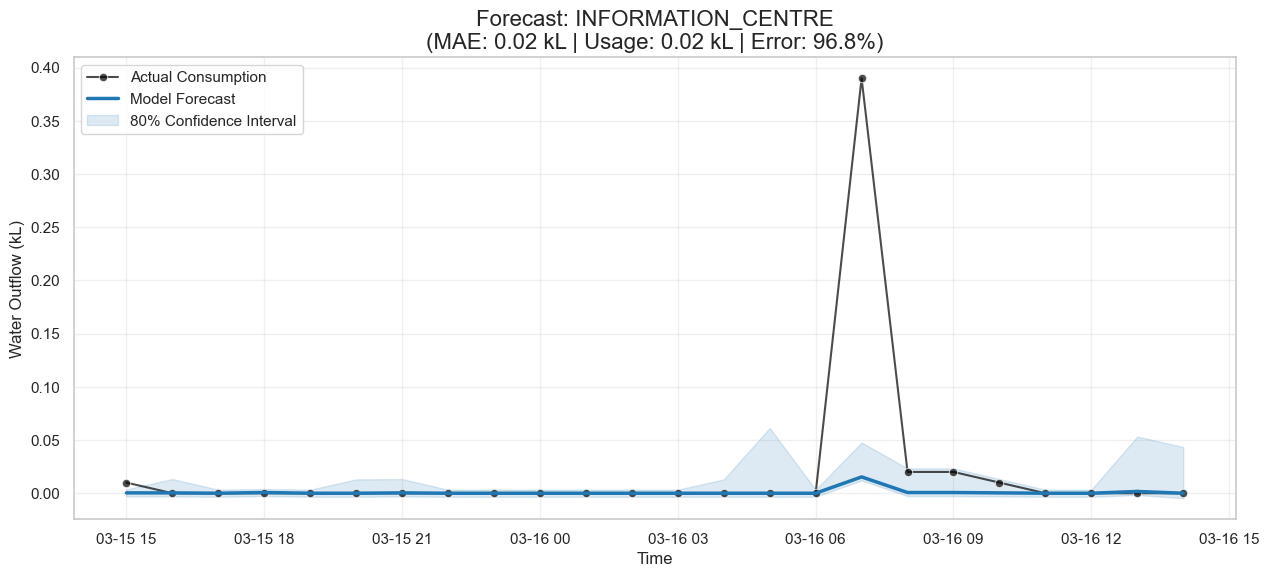

Generated plot: INFORMATION_CENTRE


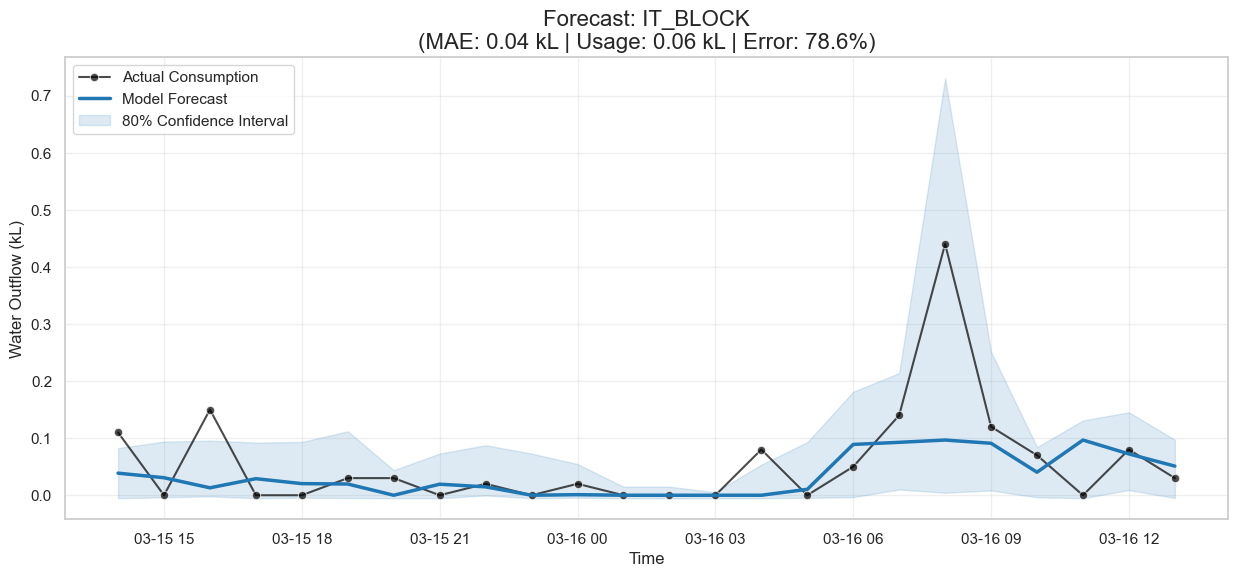

Generated plot: IT_BLOCK


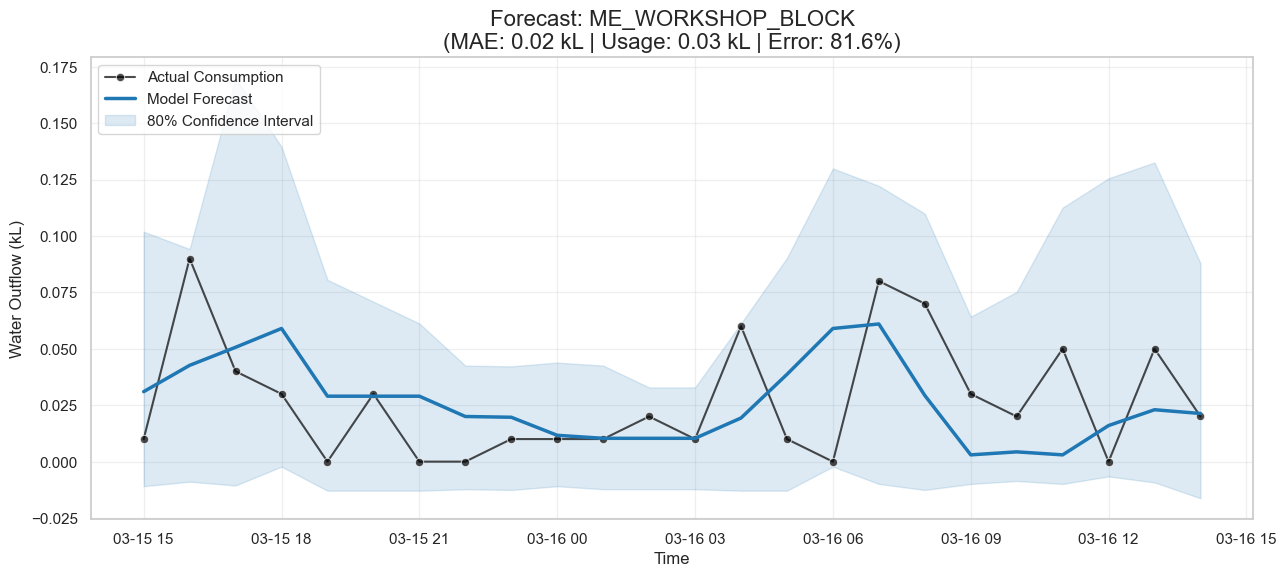

Generated plot: ME_WORKSHOP_BLOCK


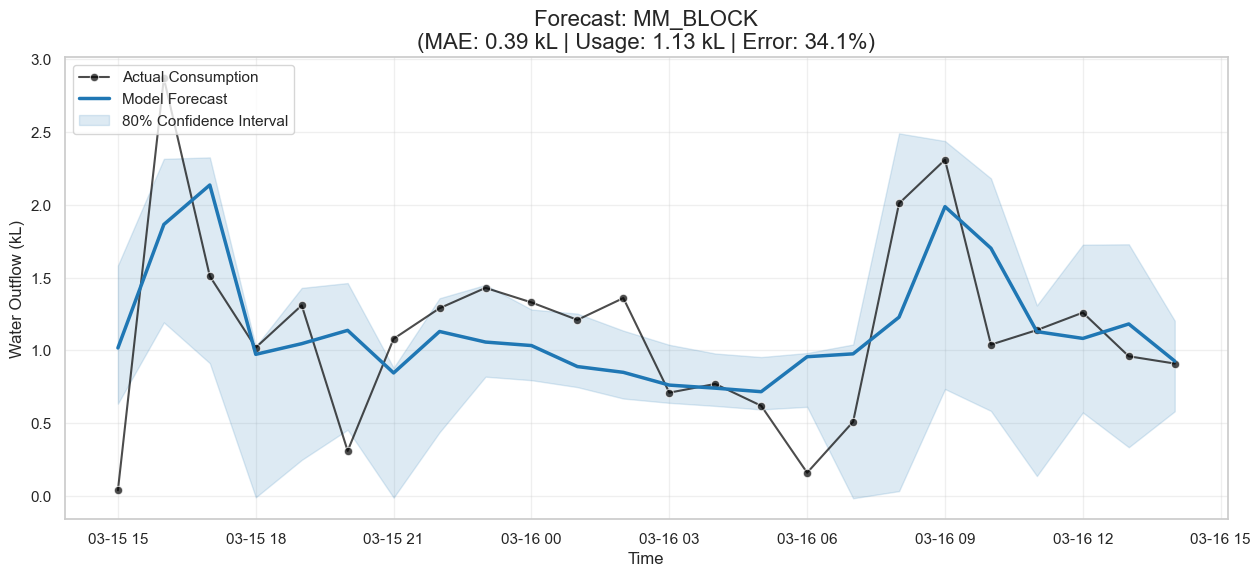

Generated plot: MM_BLOCK


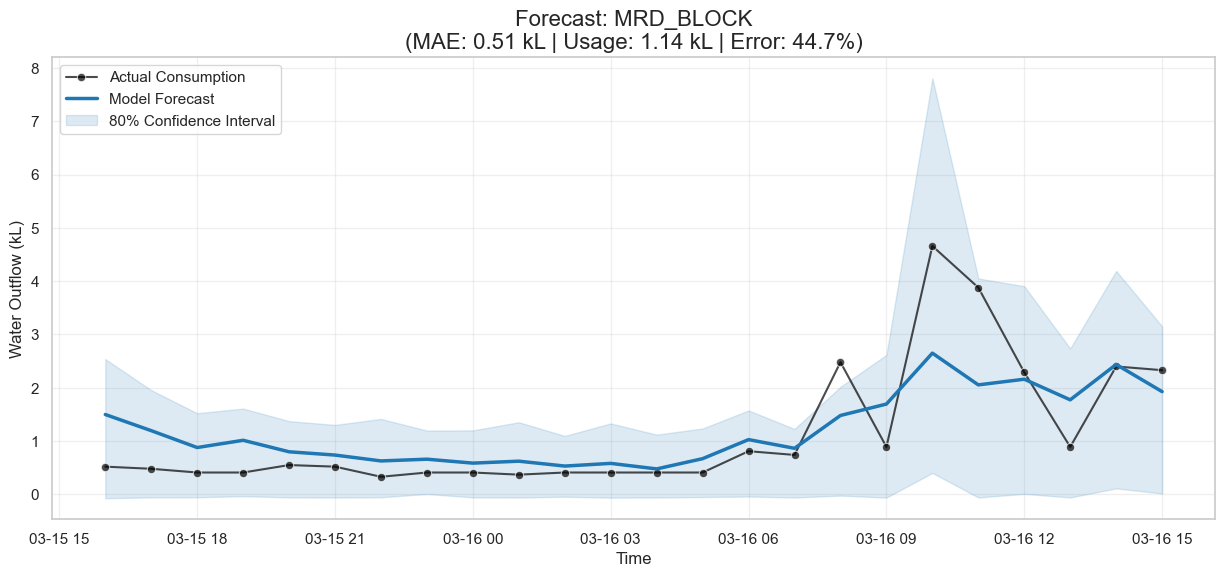

Generated plot: MRD_BLOCK


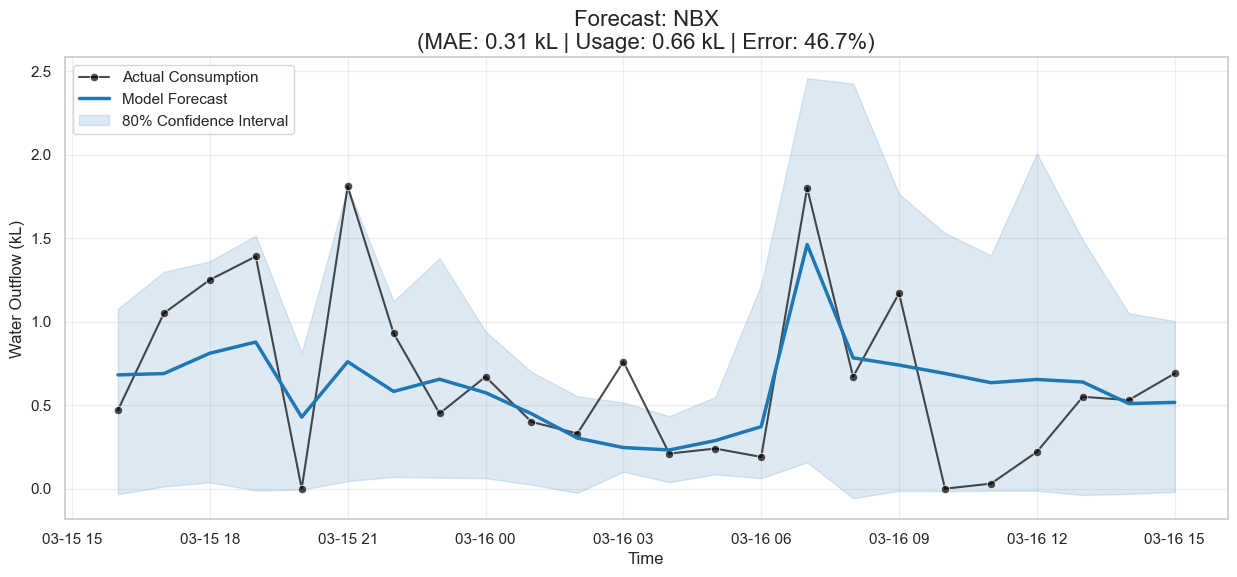

Generated plot: NBX


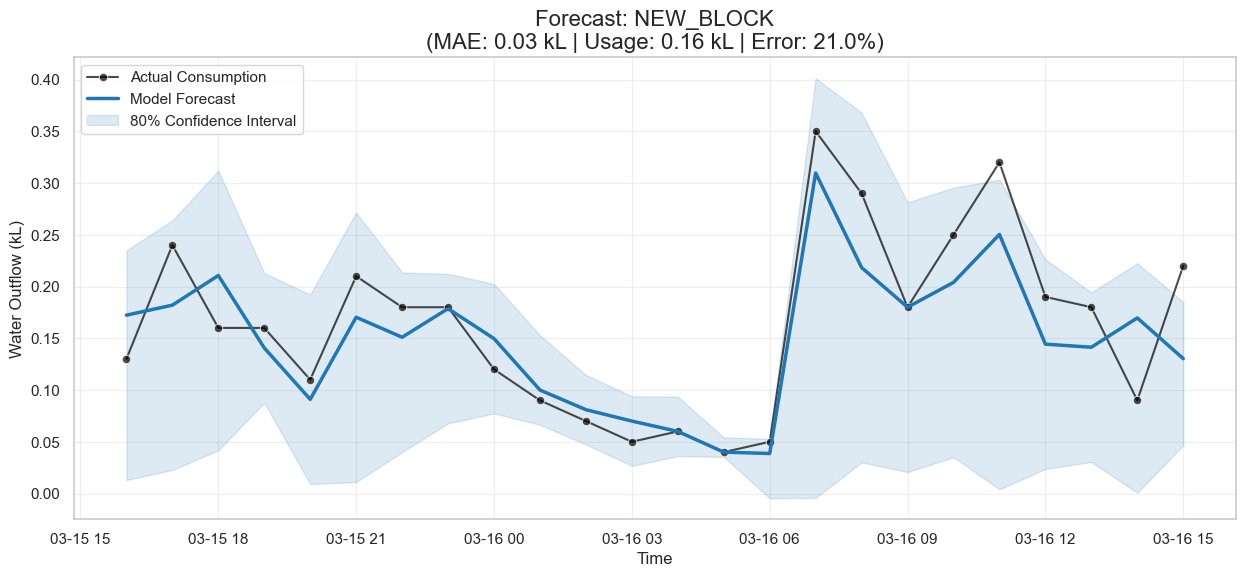

Generated plot: NEW_BLOCK


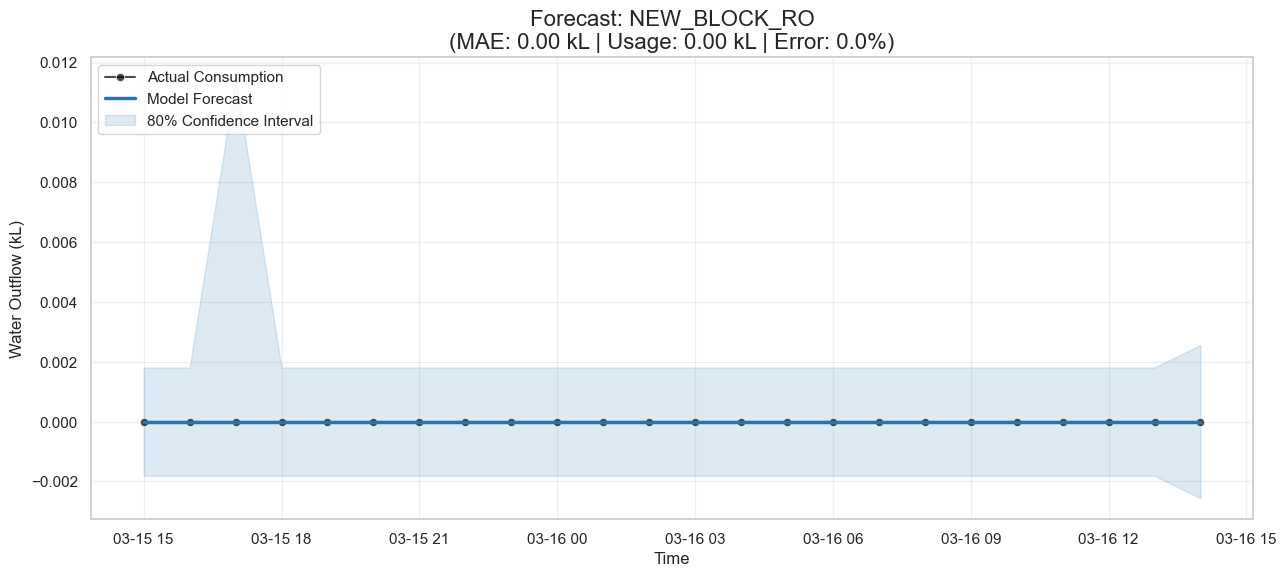

Generated plot: NEW_BLOCK_RO


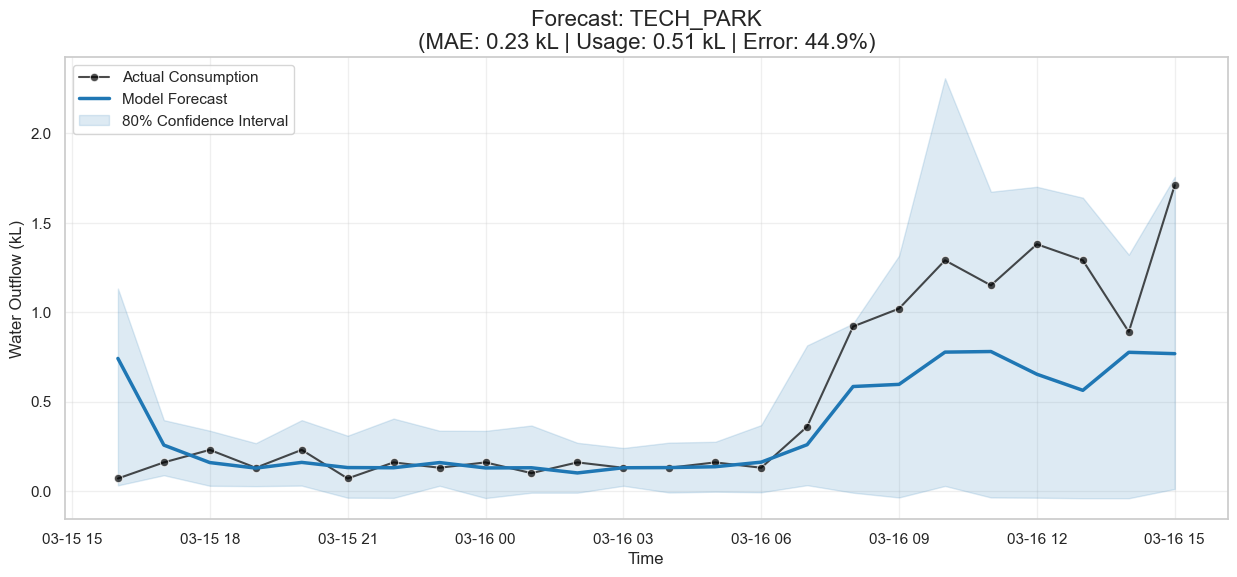

Generated plot: TECH_PARK
Done! Analysis complete.


In [18]:
# --- FINAL LOOP: ALL TANK FORECASTS ---
# Generates a detailed plot for every single tank.
# Scroll down to see specifics.

print("Generating plots for ALL tanks in the dataset...")

all_tanks = df_pred["item_id"].unique()

for tank_id in all_tanks:
    plot_tank_forecast(tank_id)
    print(f"Generated plot: {tank_id}")

print("Done! Analysis complete.")

## Future Predictions
Below, we load the forecasts generated for the next 24 hours. These can be compared against actual data tomorrow.

Loaded future predictions: 576 rows


,item_id,timestamp,pred_mean,pred_p10,0.2,0.3,0.4,pred_p50,0.6,0.7,0.8,pred_p90
0,BE_BLOCK_OHT,2026-03-16 14:00:00,1.800000,0.580560,0.974935,1.236100,1.668427,1.800000,2.115239,2.914900,3.263065,3.889440
1,BE_BLOCK_OHT,2026-03-16 15:00:00,1.729000,-0.002773,0.662268,1.097433,1.355761,1.729000,1.947573,3.046900,3.288732,4.504773
2,BE_BLOCK_OHT,2026-03-16 16:00:00,2.409000,0.561227,1.042601,1.400433,1.813427,2.409000,2.492239,3.040567,3.669065,4.527440
3,BE_BLOCK_OHT,2026-03-16 17:00:00,1.681667,0.587893,0.933935,1.272433,1.443761,1.681667,1.871239,1.887900,2.284399,3.432773
4,BE_BLOCK_OHT,2026-03-16 18:00:00,1.613333,0.674227,0.971935,1.155767,1.394761,1.613333,1.880239,1.896900,1.993732,2.552440


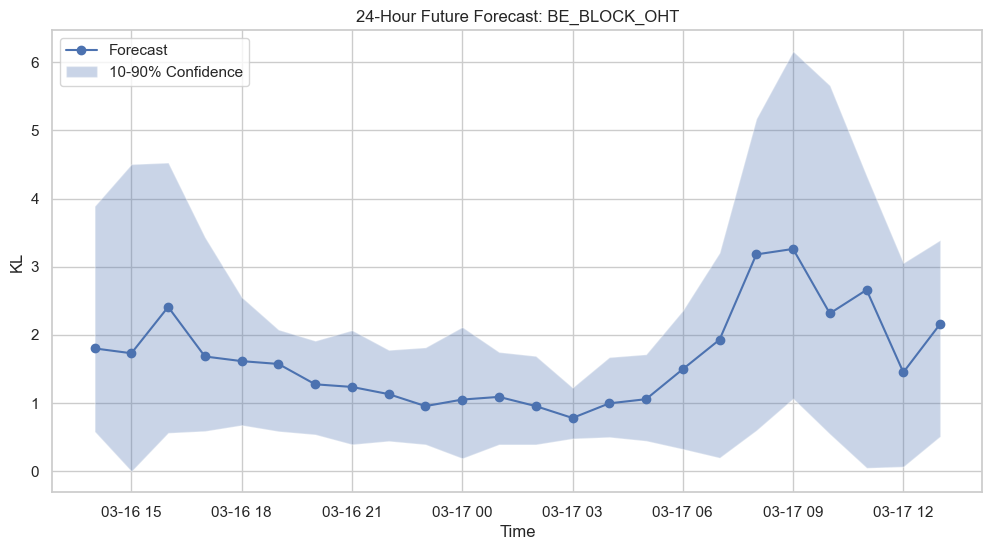

In [19]:

FUTURE_PATH = "../results/autogluon/hourly_forecasting/future_predictions_readable.csv"

if pd.io.common.file_exists(FUTURE_PATH):
    df_future = pd.read_csv(FUTURE_PATH, parse_dates=["timestamp"])
    print(f"Loaded future predictions: {len(df_future)} rows")
    display(df_future.head())
    
    # Plot forecast for a sample tank (e.g., random one or user choice)
    sample_tank = df_future['item_id'].unique()[0]
    tank_future = df_future[df_future['item_id'] == sample_tank]
    
    plt.figure(figsize=(12, 6))
    plt.plot(tank_future['timestamp'], tank_future['pred_mean'], marker='o', label='Forecast')
    plt.fill_between(tank_future['timestamp'], tank_future['pred_p10'], tank_future['pred_p90'], alpha=0.3, label='10-90% Confidence')
    plt.title(f"24-Hour Future Forecast: {sample_tank}")
    plt.xlabel("Time")
    plt.ylabel("KL")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print(f"Future predictions file not found at {FUTURE_PATH}. Please run predict_future.py.")
